In [35]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, DensityMatrix
from qiskit.circuit.library import Initialize
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.visualization import plot_histogram
from scipy.special import rel_entr
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import random
import time

In [36]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
#cc_grn_functions_path = r"C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from quantum_functions import create_initial_circuit2, concatenate_circuits_with_separate_measurements, add_cnots_and_measurements_to_circuit
from quantum_functions import add_crx_gates_and_measurements_to_circuit, get_probability_distribution, calculate_kl_divergence
from quantum_functions import score_circuit_kl_divergences, plot_measurement_histograms, create_cnot_pairs_from_locations, optimize_crx_angles
from quantum_functions import _process_target_state_input
from quantum_functions import find_best_cnot_sequence_brute_force, find_best_cnot_sequence_multi_epoch
from quantum_functions import vector_normalize_dictionary_values, find_best_cnot_sequence_iterative_n_wise

In [37]:
from qiskit import QuantumCircuit, QuantumRegister

def create_hadamard_circuit(num_qubits: int) -> QuantumCircuit:
    """
    Initializes a quantum circuit with all qubits in the |+> state by
    applying a Hadamard gate to each one.

    Args:
        num_qubits (int): The number of qubits to include in the circuit.

    Returns:
        QuantumCircuit: The initialized quantum circuit.
    """
    # Create a quantum register with the specified number of qubits.
    qr = QuantumRegister(num_qubits, name='q')
    
    # Create a quantum circuit with the quantum register.
    circuit = QuantumCircuit(qr)
    
    # Loop through each qubit and apply the Hadamard (H) gate.
    # The H gate puts the qubit into a superposition of |0> and |1>.
    for i in range(num_qubits):
        circuit.h(qr[i])
        
    return circuit

In [38]:
from qiskit import QuantumCircuit, QuantumRegister
import math

def create_rotation_circuit(angles_list: list[float]) -> QuantumCircuit:
    """
    Initializes a quantum circuit by applying a rotation gate with a
    specified angle to each qubit. The number of qubits is determined
    by the length of the angles_list.

    Args:
        angles_list (list[float]): A list of rotation angles in radians,
                                   one for each qubit.

    Returns:
        QuantumCircuit: The initialized quantum circuit.
    """
    # The number of qubits is determined by the length of the angles list.
    num_qubits = len(angles_list)
    
    # Create a quantum register with the specified number of qubits.
    qr = QuantumRegister(num_qubits, name='q')
    
    # Create a quantum circuit with the quantum register.
    circuit = QuantumCircuit(qr)

    for i in range(num_qubits):
        circuit.ry(angles_list[i], qr[i])
        
    return circuit

In [39]:
# Create the circuit using the function
ang_4g = [np.pi*0.4, np.pi*0.1, np.pi*0.6, np.pi*0.2]
#ang_4g = [np.pi*0, np.pi*0, np.pi*1, np.pi*1]
circuit_4g = create_rotation_circuit(ang_4g)

# Create the circuit using the function
ang_3g = [np.pi*0.6, np.pi*0.3, np.pi*0.25]
#ang_3g = [np.pi*1, np.pi*1, np.pi*0]
circuit_3g = create_rotation_circuit(ang_3g)

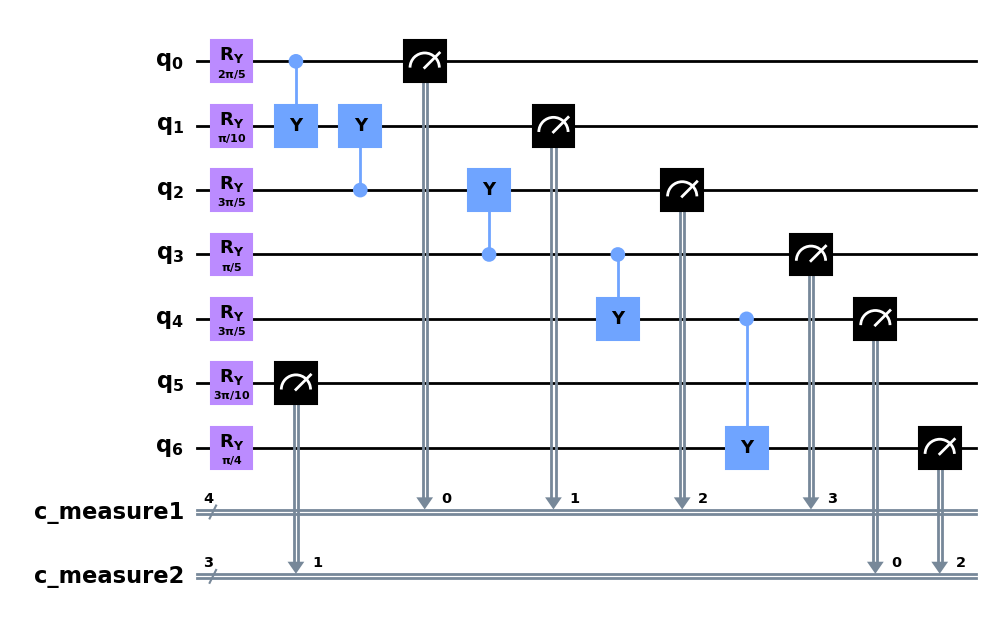

In [40]:
circuit_xct = concatenate_circuits_with_separate_measurements(circuit_4g, circuit_3g)
interaction_map = list([(0,1), (2,1), (3,2), (3,4), (4, 6)])
#interaction_map = list([(1, 0)])

circuit_xct_cnot = add_cnots_and_measurements_to_circuit(circuit_xct, circuit_4g.num_qubits, interaction_map )
circuit_xct_cnot.draw(output="mpl", style="clifford", fold=40,  scale = 1.0)


--- Simulating and Plotting Histograms for: Greedy Optimized Circuit ---
Counts for c_measure1: {'0110': 756, '0011': 186, '0000': 399, '1111': 19, '0101': 427, '1100': 41, '1010': 77, '0100': 23, '0111': 16, '1001': 38, '1000': 3, '0010': 9, '1011': 3, '0001': 3}
Counts for c_measure2: {'000': 517, '110': 24, '101': 849, '111': 225, '010': 133, '100': 72, '001': 153, '011': 27}


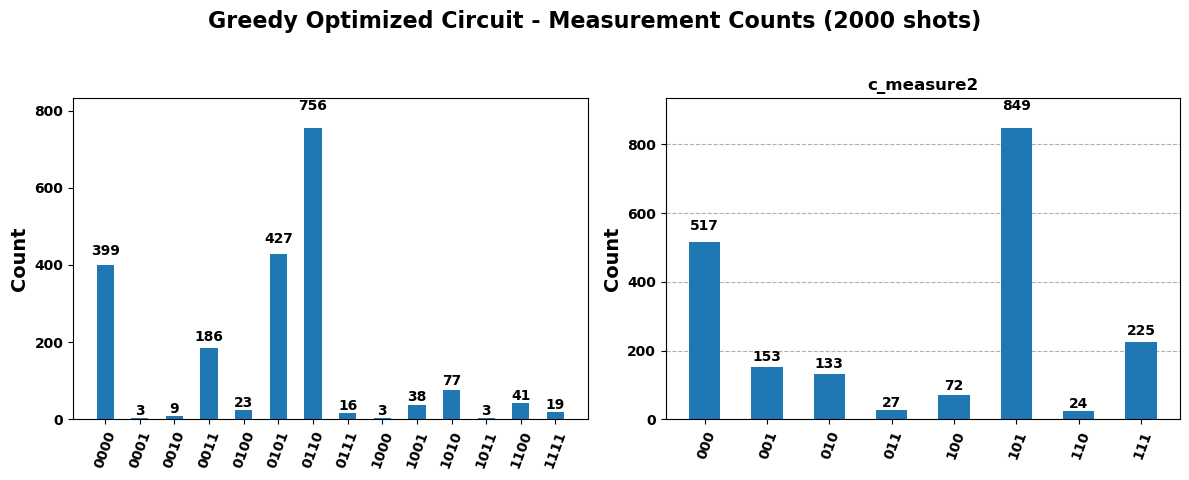

In [41]:
counts_measure1, counts_measure2 = plot_measurement_histograms(circuit_xct_cnot, nshots=2000, title_prefix="Greedy Optimized Circuit")

In [42]:
import numpy as np

def create_binary_matrix(joint_counts: dict):
    """
    Generates a binary matrix from a joint histogram dictionary with 0s and 1s.

    Args:
        joint_counts (dict): A dictionary where keys are bit strings
                             (representing rows) and values are their counts.

    Returns:
        np.ndarray: A reconstructed binary matrix with integer values.
    """
    if not joint_counts:
        return np.array([], dtype=int).reshape(0, 0)
    
    # Get the number of genes (columns) from the length of the first key
    first_key = next(iter(joint_counts.keys()))
    num_genes = len(first_key)
    
    reconstructed_rows = []

    # Iterate through the joint counts
    for bit_string, count in joint_counts.items():
        # Reverse the bit string to align with the original g0, g1, ... order
        reversed_bit_string = bit_string[::-1]
        
        # Convert the reversed bit string to a list of integer values (0 or 1)
        row_values = [int(char) for char in reversed_bit_string]
        
        # Repeat the row 'count' number of times
        for _ in range(count):
            reconstructed_rows.append(row_values)
            
    # Convert the list of lists into a NumPy array with integer dtype
    return np.array(reconstructed_rows, dtype=int)

In [43]:
# Reconstruct the matrix
reconstructed_matrix = create_binary_matrix(counts_measure1)
print("Reconstructed Binary Matrix 1:")
print(reconstructed_matrix)
print("\nShape of the reconstructed matrix 1:", reconstructed_matrix.shape)

Reconstructed Binary Matrix 1:
[[0 1 1 0]
 [0 1 1 0]
 [0 1 1 0]
 ...
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]]

Shape of the reconstructed matrix 1: (2000, 4)


In [44]:
# Reconstruct the matrix
reconstructed_matrix2 = create_binary_matrix(counts_measure2)
print("Reconstructed Binary Matrix 1:")
print(reconstructed_matrix2)
print("\nShape of the reconstructed matrix 1:", reconstructed_matrix2.shape)

Reconstructed Binary Matrix 1:
[[0 0 0]
 [0 0 0]
 [0 0 0]
 ...
 [1 1 0]
 [1 1 0]
 [1 1 0]]

Shape of the reconstructed matrix 1: (2000, 3)


In [45]:
import numpy as np
import pandas as pd
import anndata as ad
from scipy.stats import nbinom
import scanpy as sc

# --- Re-using the gene count matrix function for demonstration ---
def create_count_matrix_nbinom(binary_matrix: np.ndarray, mu_vector: np.ndarray, r_vector: np.ndarray):
    """
    Creates a count matrix from a binary matrix using a Negative Binomial distribution
    with gene-specific mean and dispersion parameters.
    """
    num_cells, num_genes = binary_matrix.shape
    
    if len(mu_vector) != num_genes or len(r_vector) != num_genes:
        raise ValueError("The length of mu_vector and r_vector must match the number of genes.")
        
    count_matrix = np.zeros_like(binary_matrix, dtype=np.int32)
    
    for j in range(num_genes):
        on_indices = np.where(binary_matrix[:, j] == 1)[0]
        mu_j = mu_vector[j]
        r_j = r_vector[j]
        p_j = r_j / (mu_j + r_j)
        random_counts = nbinom.rvs(n=r_j, p=p_j, size=len(on_indices))
        count_matrix[on_indices, j] = random_counts
        
    return count_matrix

In [46]:
# Genes generated with stringdb:    https://string-db.org/cgi/network?taskId=bJEFw413SU2h&sessionId=bcTc0aENh3tL
# --- Step 1: Create the first AnnData object (representing one cell type) ---
print("Creating the first AnnData object (adata1)...")

# Simulating the first dataset's parameters
num_cells1 = 2000
gene_names1 = ['TGFBR2', 'FLT4', 'KDR', 'PDGFB']

# Set these genes to be highly expressed in this population
mu_vector1 = np.array([50.0, 100.0, 80.0, 40.0])
r_vector1 = np.array([0.5, 0.8, 0.6, 0.4])

# Create dummy data for adata1
np.random.seed(100)
binary_matrix1 = np.random.randint(0, 2, size=(num_cells1, len(gene_names1)))
count_matrix1 = create_count_matrix_nbinom(binary_matrix1, mu_vector1, r_vector1)

cell_ids1 = [f'cell_{i}_ds1' for i in range(num_cells1)]
obs1 = pd.DataFrame(index=cell_ids1)
var1 = pd.DataFrame(index=gene_names1)

# Create the AnnData object for the first dataset
adata1 = ad.AnnData(X=count_matrix1, obs=obs1, var=var1)
print(f"adata1 shape: {adata1.shape}")
print(f"adata1 genes: {adata1.var_names.tolist()}")

Creating the first AnnData object (adata1)...
adata1 shape: (2000, 4)
adata1 genes: ['TGFBR2', 'FLT4', 'KDR', 'PDGFB']


In [47]:
# --- Step 2: Create the second AnnData object (representing another cell type) ---
print("\nCreating the second AnnData object (adata2)...")

num_cells2 = 2000
gene_names2 = ['TGFB1', 'NRP1', 'PDGFRB']

# Set these genes to be highly expressed in this population
mu_vector2 = np.array([100.0, 80.0, 60.0])
r_vector2 = np.array([0.8, 0.6, 0.4])

# Create dummy data for adata2
np.random.seed(200)
binary_matrix2 = np.random.randint(0, 2, size=(num_cells2, len(gene_names2)))
count_matrix2 = create_count_matrix_nbinom(binary_matrix2, mu_vector2, r_vector2)
cell_ids2 = [f'cell_{i}_ds2' for i in range(num_cells2)]
obs2 = pd.DataFrame(index=cell_ids2)
var2 = pd.DataFrame(index=gene_names2)

# Create the AnnData object for the second dataset
adata2 = ad.AnnData(X=count_matrix2, obs=obs2, var=var2)
print(f"adata2 shape: {adata2.shape}")
print(f"adata2 genes: {adata2.var_names.tolist()}")



Creating the second AnnData object (adata2)...
adata2 shape: (2000, 3)
adata2 genes: ['TGFB1', 'NRP1', 'PDGFRB']


In [48]:
# --- Step 3: Add housekeeping genes ---
print("\nAdding 10 random housekeeping genes to both datasets...")

num_housekeeping_genes = 20
housekeeping_gene_names = [f'HKG_{i}' for i in range(num_housekeeping_genes)]

# Housekeeping genes are highly and consistently expressed across all cells
mu_hkg = np.full(num_housekeeping_genes, 100.0)
r_hkg = np.full(num_housekeeping_genes, 5.0) # High r for low dispersion

# Create a binary matrix with 1s for all housekeeping genes across all cells
binary_matrix_hkg = np.ones((num_cells1 + num_cells2, num_housekeeping_genes), dtype=int)
count_matrix_hkg = create_count_matrix_nbinom(binary_matrix_hkg, mu_hkg, r_hkg)

# Create an AnnData object for the housekeeping genes
hkg_adata = ad.AnnData(
    X=count_matrix_hkg,
    obs=pd.DataFrame(index=list(adata1.obs_names) + list(adata2.obs_names)),
    var=pd.DataFrame(index=housekeeping_gene_names)
)

# --- Step 4: Merge the datasets ---
print("\nMerging all three AnnData objects...")

# First, merge adata1 and adata2 by cells
merged_cell_adata = ad.concat(
    [adata1, adata2],
    axis=0,
    join='outer',
    label='batch',
    keys=['ds1', 'ds2']
)

# Fill any NaN values with 0
merged_cell_adata.X[np.isnan(merged_cell_adata.X)] = 0

# Then, merge the combined dataset with the housekeeping genes by features
merged_adata = ad.concat(
    [merged_cell_adata, hkg_adata],
    axis=1,
    join='inner',
    merge='unique'
)

print("\nFinal Merged AnnData object created:")
print(merged_adata)
print(f"Merged shape: {merged_adata.shape}")
print(f"Merged genes: {merged_adata.var_names.tolist()}")

# --- Step 5: Save the merged object to an h5ad file ---
merged_adata.write_h5ad('merged_datasets.h5ad')
print("\nSuccessfully saved the merged AnnData object to merged_datasets.h5ad")



Adding 10 random housekeeping genes to both datasets...

Merging all three AnnData objects...

Final Merged AnnData object created:
AnnData object with n_obs × n_vars = 4000 × 27
    obs: 'batch'
Merged shape: (4000, 27)
Merged genes: ['FLT4', 'KDR', 'NRP1', 'PDGFB', 'PDGFRB', 'TGFB1', 'TGFBR2', 'HKG_0', 'HKG_1', 'HKG_2', 'HKG_3', 'HKG_4', 'HKG_5', 'HKG_6', 'HKG_7', 'HKG_8', 'HKG_9', 'HKG_10', 'HKG_11', 'HKG_12', 'HKG_13', 'HKG_14', 'HKG_15', 'HKG_16', 'HKG_17', 'HKG_18', 'HKG_19']

Successfully saved the merged AnnData object to merged_datasets.h5ad


In [49]:
# --- Step 5: Save the merged object to an h5ad file ---
merged_adata.write_h5ad('merged_datasets.h5ad')
print("\nSuccessfully saved the merged AnnData object to merged_datasets.h5ad")

# --- Step 6: Processing the data with Scanpy ---
print("\nStarting data processing with Scanpy...")

# Load the merged AnnData object
adata = merged_adata.copy()

# The 'batch' column is already in obs from the `ad.concat` step.
print("\nDataset batches are now stored in adata.obs['batch']:")
print(adata.obs['batch'].value_counts())

# --- 6.1 Quality Control (QC) and Metrics ---
sc.pp.calculate_qc_metrics(adata, inplace=True, percent_top=None)

# --- 6.2 Normalization and Log-Transformation ---
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# --- 6.3 Scaling the Data ---
sc.pp.scale(adata, max_value=10)

# --- 6.4 Principal Component Analysis (PCA) ---
# Check if the number of genes is sufficient for PCA
if adata.n_vars > 0:
    sc.tl.pca(adata, svd_solver='arpack')
else:
    print("\nNo genes remaining after filtering. Skipping PCA.")

# --- 6.5 UMAP (Uniform Manifold Approximation and Projection) ---
# Set n_pcs to be the minimum of 20 and the number of genes
n_pcs = min(10, adata.n_vars)
if adata.n_vars > 1:
    sc.pp.neighbors(adata, n_neighbors=10, n_pcs=n_pcs)
    sc.tl.umap(adata)
    sc.tl.leiden(adata, flavor="leidenalg", n_iterations=2)

else:
    print("\nNot enough genes to compute neighbors and UMAP. Skipping.")

# --- 6.7 Final Output ---
print("\nFinal AnnData object after UMAP has been computed:")
print(adata)
print("\nUMAP coordinates are stored in adata.obsm['X_umap'].")
print("PCA coordinates are stored in adata.obsm['X_pca'].")



Successfully saved the merged AnnData object to merged_datasets.h5ad

Starting data processing with Scanpy...

Dataset batches are now stored in adata.obs['batch']:
batch
ds1    2000
ds2    2000
Name: count, dtype: int64

Final AnnData object after UMAP has been computed:
AnnData object with n_obs × n_vars = 4000 × 27
    obs: 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mean', 'std'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

UMAP coordinates are stored in adata.obsm['X_umap'].
PCA coordinates are stored in adata.obsm['X_pca'].


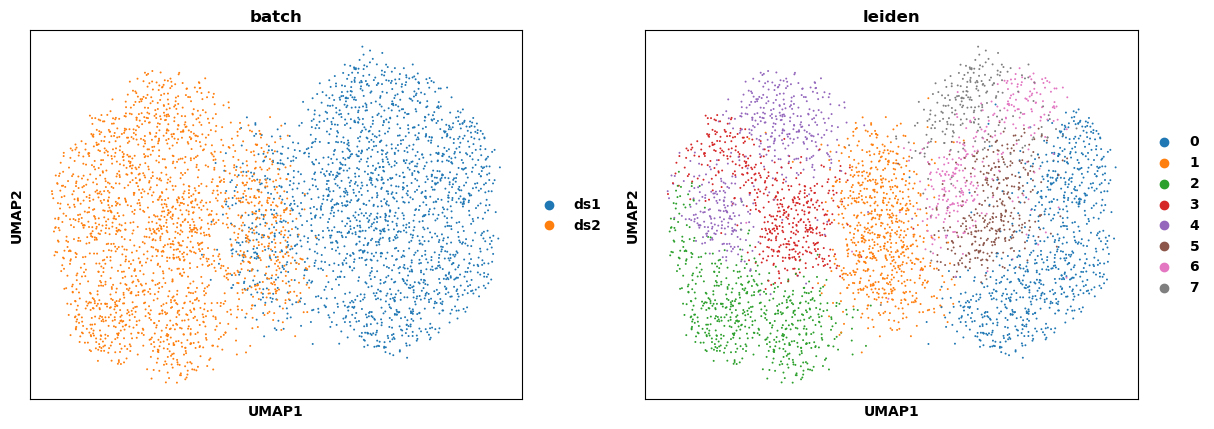

In [50]:
sc.pl.umap(
    adata,
    color=["batch", "leiden"],
    # Setting a smaller point size to get prevent overlap
    size=8,
)

In [72]:
import pandas as pd
import numpy as np
import scanpy as sc

# Check if adata.X is a sparse matrix, convert to dense if necessary
# This makes your code robust to different data formats
if isinstance(adata.X, np.ndarray):
    gene_expression_matrix = adata.X.T
else: # assuming it's a sparse matrix
    gene_expression_matrix = adata.X.T.toarray()

# Create the DataFrame
gene_expression_df = pd.DataFrame(
    gene_expression_matrix,
    index=adata.var_names,
    columns=adata.obs_names
)

# Calculate the correlation matrix.
corr_matrix = gene_expression_df.T.corr(method='pearson')

# Filter for strong correlations to simplify the network.
# A common threshold is an absolute correlation of 0.5 or higher.
threshold = 0.2
adj_matrix = np.where(np.abs(corr_matrix) > threshold, corr_matrix, 0)
np.fill_diagonal(adj_matrix, 0)

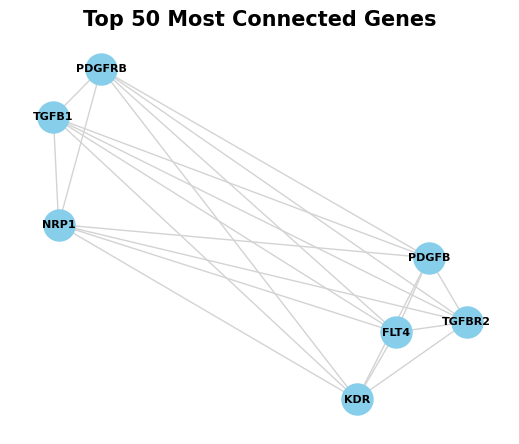

In [73]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a graph object from the adjacency matrix
G = nx.from_numpy_array(adj_matrix)

# Map the integer indices back to gene names
gene_names = adata.var_names
mapping = {i: gene_names[i] for i in range(len(gene_names))}
G = nx.relabel_nodes(G, mapping)

# Remove nodes that have no connections (isolated genes)
G.remove_nodes_from(list(nx.isolates(G)))

# To get a cleaner plot of a sub-network, you can find the most highly connected genes
degrees = dict(G.degree())
most_connected_genes = sorted(degrees, key=degrees.get, reverse=True)[:50]
subgraph = G.subgraph(most_connected_genes)

# Set a new layout specifically for the subgraph
subgraph_pos = nx.fruchterman_reingold_layout(subgraph)

plt.figure(figsize=(5, 4))
nx.draw(subgraph,
        pos=subgraph_pos,  # Use the new layout here
        with_labels=True,
        node_size=500,
        font_size=8,
        node_color='skyblue',
        edge_color='lightgray')
plt.title("Top 50 Most Connected Genes", fontsize=15)
plt.show()